In [1]:
import numpy as np

from matplotlib.markers import MarkerStyle
from matplotlib.lines import Line2D

import superconductivity.api as sc

from superconductivity.api import G0_muS
from superconductivity.api import NDArray64

from IPython import get_ipython

_ip = get_ipython()
if _ip is not None:
    _ip.run_line_magic("reload_ext", "autoreload")
    _ip.run_line_magic("autoreload", "2")

    _ip.run_line_magic(
        "config",
        "InlineBackend.print_figure_kwargs = {'bbox_inches': None, 'pad_inches': 0.0}",
    )
    _ip.run_line_magic("config", 'InlineBackend.figure_format = "retina"')  # or "png"
    _ip.run_line_magic(
        "config", "InlineBackend.rc = {'figure.dpi': 300}"
    )  # choose a value you like

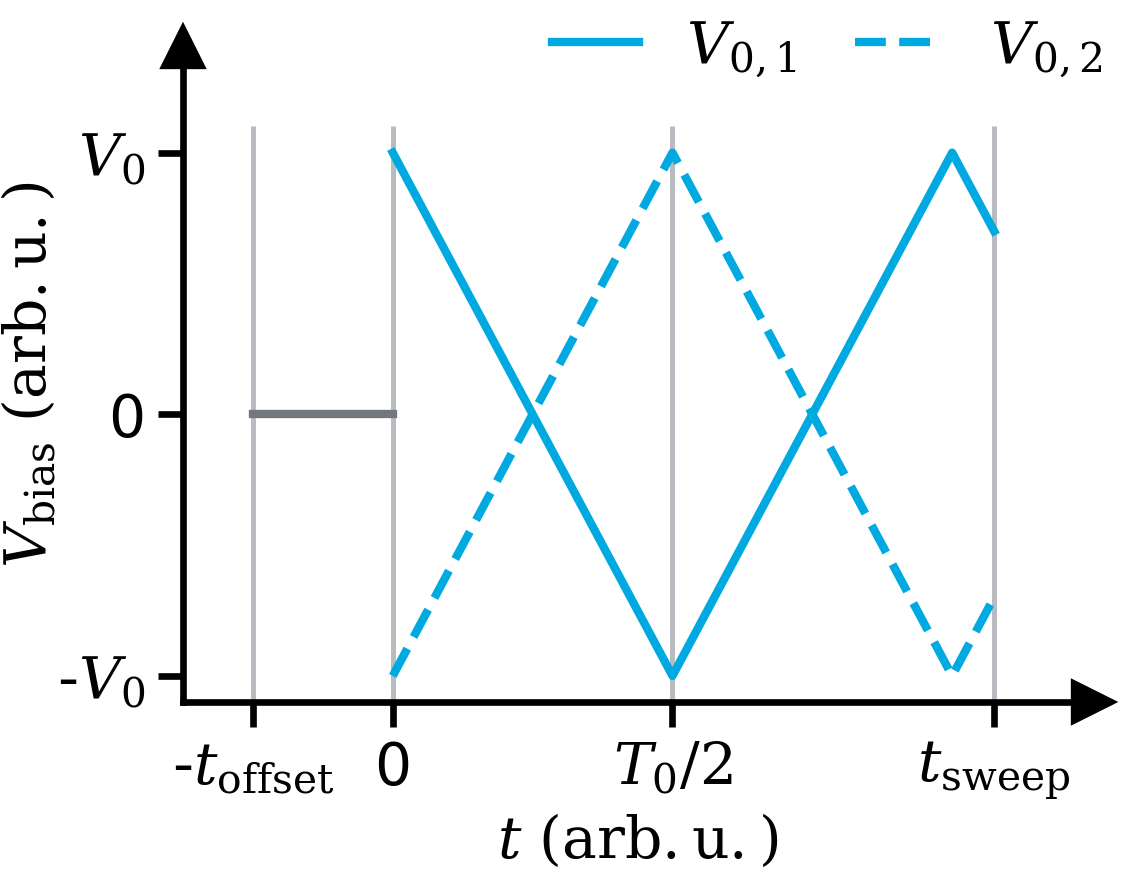

In [2]:
# ivscript
figsize = (1.9, 1.45)
fig, ax = sc.get_figure(figsize=figsize, padding=(0.225, 0.2))

ax.plot([0, 1], [0, 0], color=sc.seegrau100)
ax.plot([1, 3, 5, 5.3], [1, -1, 1, 0.7], "-", color=sc.seeblau100, label="$V_{0, 1}$")
ax.plot(
    [1, 3, 5, 5.3], [-1, 1, -1, -0.7], "--", color=sc.seeblau100, label="$V_{0, 2}$"
)

ylim = -1.1, 1.1
ax.set_xticks(
    [0, 1, 3, 5.3],
    labels=["-$t_\\mathrm{offset}$", "0", "$T_0/2$", "$t_\\mathrm{sweep}$"],
)
ax.set_yticks([-1, 0, 1], labels=["-$V_0$", "0", "$V_0$"])
ax.set_ylim(ylim)
# ax.grid(
#     axis="x",
# )

for x in [0, 1, 3, 5.3]:
    ax.vlines(x, *ylim, color=sc.seegrau35, lw=0.6, zorder=0)

ax.set_xlim(-0.5, 6)
ax.set_ylim(None, 1.4)

ax.legend(
    handlelength=1.5,
    loc="upper right",
    bbox_to_anchor=(1.05, 1.1),
    frameon=False,
    fontsize=7,
    title_fontsize=7,
    ncols=2,
    columnspacing=1.0,
    borderpad=0.1,  # reduces padding inside the legend box
)

xlabel = "$t\\ \\mathrm{(arb. u.)}$"
ylabel = "$V_\\mathrm{bias}\\ \\mathrm{(arb. u.)}$"
# xlabel = ""
# ylabel = ""
title = "methods/digital/ivscript"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

In [168]:
# # get data, keys, traces, offset, sample

# from superconductivity.utilities import make_cache
# from superconductivity.utilities import save_cache
# from superconductivity.evaluation import FileSpec
# from superconductivity.evaluation import KeysSpec
# from superconductivity.evaluation import get_keys
# from superconductivity.evaluation import TraceSpec
# from superconductivity.evaluation import get_traces
# from superconductivity.evaluation import OffsetSpec
# from superconductivity.evaluation import offset_analysis
# from superconductivity.evaluation import SamplingSpec
# from superconductivity.evaluation import sample

# cache = make_cache("cache", path="digital/")

# cache.filespec = FileSpec(
#     h5path="OI-25c-09 2025-05-02 unbroken stripline irradiation studies 0.hdf5",
#     location="/Users/oliver/Documents/measurement data/25 04 OI-25c-09",
#     measurement="vna_amplitudes_18.3000GHz",
# )
# mkeys = cache.filespec.mkeys()
# skeys = cache.filespec.skeys()

# cache.keysspec = KeysSpec(
#     strip0="GHz_",
#     strip1="V",
#     remove_key="no_irradiation",
#     add_key=[
#         ("no_irradiation", 0.0),
#         ("no_irradiation", 0.005),
#     ],
#     norm=1e-3,
#     limits=(None, 2),
#     label="Aout_mV",
# )

# cache.skeys = get_keys(
#     filespec=cache.filespec,
#     keysspec=cache.keysspec,
# )

# cache.tracespec = TraceSpec(
#     AmpV=1000,
#     AmpI=1000,
#     trigger_values=1,
#     skip_edges=5,
# )

# cache.traces = get_traces(
#     filespec=cache.filespec,
#     keysspec=cache.keysspec,
#     tracespec=cache.tracespec,
# )

# cache.offsetspec = OffsetSpec(
#     Vbins_mV=np.linspace(-0.5, 0.5, 51),
#     Ibins_nA=np.linspace(-5.0, 5.0, 51),
#     Voffscan_mV=np.linspace(-0.045, 0.045, 451),
#     Ioffscan_nA=np.linspace(-0.35, 0.35, 351),
#     cutoff_Hz=7.3,
#     sampling_Hz=137.0,
# )

# cache.offsetanalysis = offset_analysis(
#     traces=cache.traces,
#     spec=cache.offsetspec,
# )

# cache.samplingspec = SamplingSpec(
#     Vbins_mV=np.linspace(-1.6, 1.6, 6401),
#     Ibins_nA=np.linspace(-30.0, 30.0, 801),
#     Voff_mV=cache.offsetanalysis.Voff_mV,
#     Ioff_nA=cache.offsetanalysis.Ioff_nA,
#     apply_smoothing=False,
#     cutoff_Hz=7.3,
#     sampling_Hz=137.0,
#     median_bins=3,
#     sigma_bins=2.0,
# )
# cache.exp_v, cache.exp_i = sample(
#     traces=cache.traces,
#     samplingspec=cache.samplingspec,
# )

# _ = save_cache(cache)

In [169]:
# derive values

from superconductivity.utilities import load_cache

cache = load_cache("cache", path="digital/")

traces = cache.traces
Iraw_nA = traces.I_nA[0]
Vraw_uV = traces.V_mV[0] * 1e3

Voff_uV, Ioff_nA = (
    cache.offsetanalysis.Voff_mV[0] * 1e3,
    cache.offsetanalysis.Ioff_nA[0],
)

low_pass = traces.low_pass(cutoff_Hz=7.3)
low_pass = low_pass.resample(nu_Hz=137.0)
Ilow_nA = low_pass.I_nA[0]
Vlow_uV = low_pass.V_mV[0] * 1e3

Ilow_nA -= Ioff_nA
Vlow_uV -= Voff_uV

Iraw_nA -= Ioff_nA
Vraw_uV -= Voff_uV

Ibinv_nA = cache.exp_v.I_nA[0]
Vbinv_uV = cache.exp_v.V_mV * 1e3

Ibini_nA = cache.exp_i.I_nA
Vbini_uV = cache.exp_i.V_mV[0] * 1e3

dV2_uV = (Vbinv_uV[1] - Vbinv_uV[0]) / 2
dI2_nA = (Ibini_nA[1] - Ibini_nA[0]) / 2

In [170]:
# figure settings
figsize = (2.0, 1.6)
padding = (0.25, 0.2)

xlabel = "$V\\ \\mathrm{(\\mu V)}$"
ylabel = "$I\\ \\mathrm{(nA)}$"

xlim0 = 0, 550

xlim_glob, ylim_glob = (
    (np.float64(378.94473268983137), np.float64(397.0661808478478)),
    (np.float64(1.1856922518149613), np.float64(3.375556150716729)),
)

In [171]:
# Bild vor Ton
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerBase


class HandlerDoubleLine(HandlerBase):
    def create_artists(
        self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans
    ):
        color = orig_handle.get_color()
        lw = orig_handle.get_linewidth()
        lw = 0.1

        y1 = ydescent + 0.20 * height
        y2 = ydescent + 0.80 * height

        line1 = Line2D(
            [xdescent, xdescent + width],
            [y1, y1],
            color=color,
            linewidth=lw,
            transform=trans,
        )
        line2 = Line2D(
            [xdescent, xdescent + width],
            [y2, y2],
            color=color,
            linewidth=lw,
            transform=trans,
        )

        return [line1, line2]

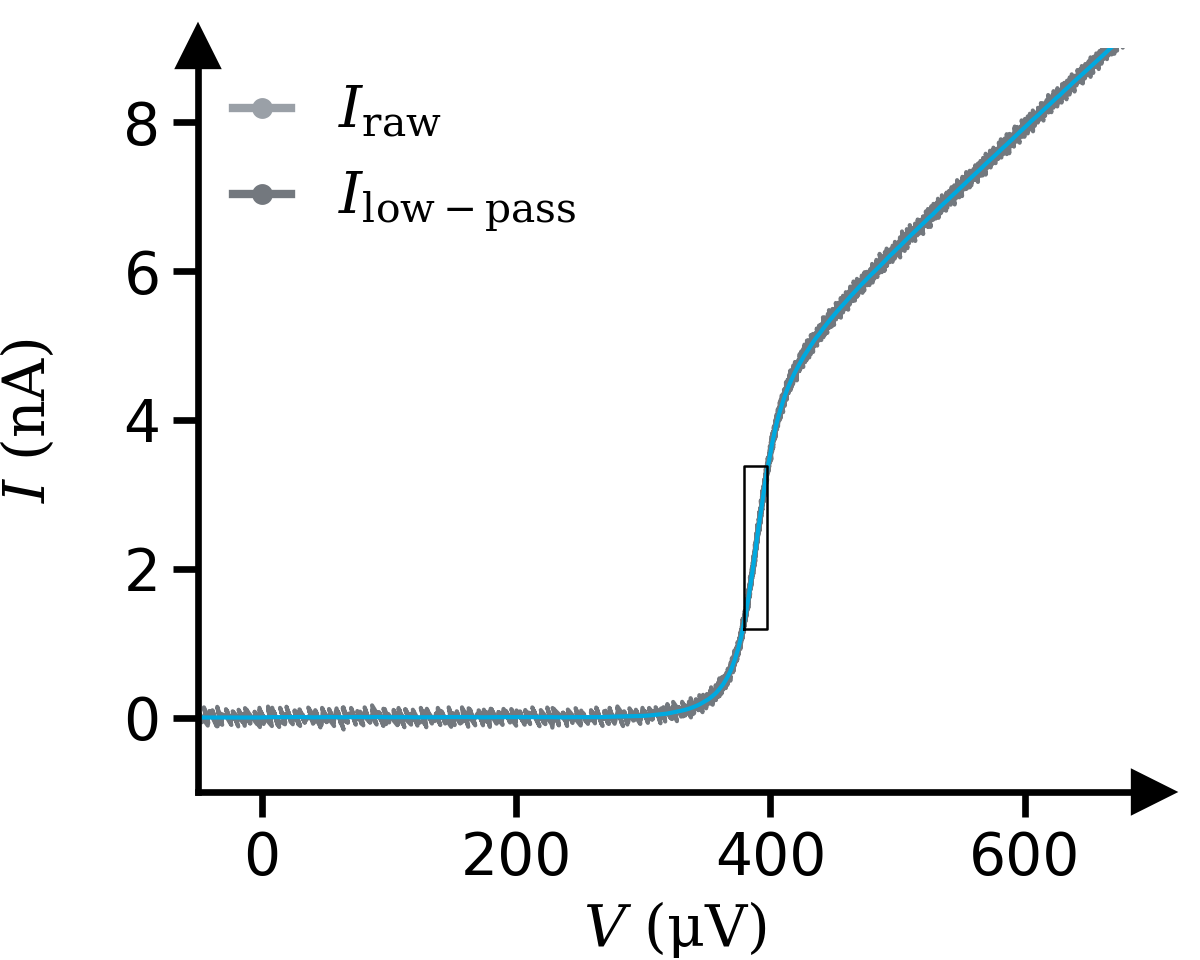

In [172]:
# raw + low-pass
fig, ax = sc.get_figure(figsize=figsize, padding=padding)

ax.plot(
    Vraw_uV,
    Iraw_nA,
    "-",
    lw=0.5,
    ms=1.0,
    color=sc.seegrau100,
)
ax.plot(
    Vlow_uV,
    Ilow_nA,
    "-",
    lw=0.5,
    ms=1.0,
    color=sc.seeblau100,
)
ax.plot(
    [xlim_glob[0], xlim_glob[1], xlim_glob[1], xlim_glob[0], xlim_glob[0]],
    [ylim_glob[0], ylim_glob[0], ylim_glob[1], ylim_glob[1], ylim_glob[0]],
    "-",
    lw=0.3,
    color="k",
)

ax.plot(
    [],
    [],
    ".-",
    ms=3.0,
    lw=1.0,
    color=sc.seegrau65,
    label="$I_\mathrm{raw}$",
)
ax.plot(
    [],
    [],
    ".-",
    ms=3.0,
    lw=1.0,
    color=sc.seegrau100,
    label="$I_\mathrm{low-pass}$",
)

leg = ax.legend(
    handlelength=1.0,
    loc="upper left",
    # bbox_to_anchor=(0.03, 1.0),
    frameon=False,
    fontsize=7,
    title_fontsize=7,
    # ncols=2,
    columnspacing=1.0,
    borderpad=0.1,  # reduces padding inside the legend box
)

ax.set_ylim(-1, 9)
ax.set_xlim(-50, 700)

title = "methods/digital/eva_0"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

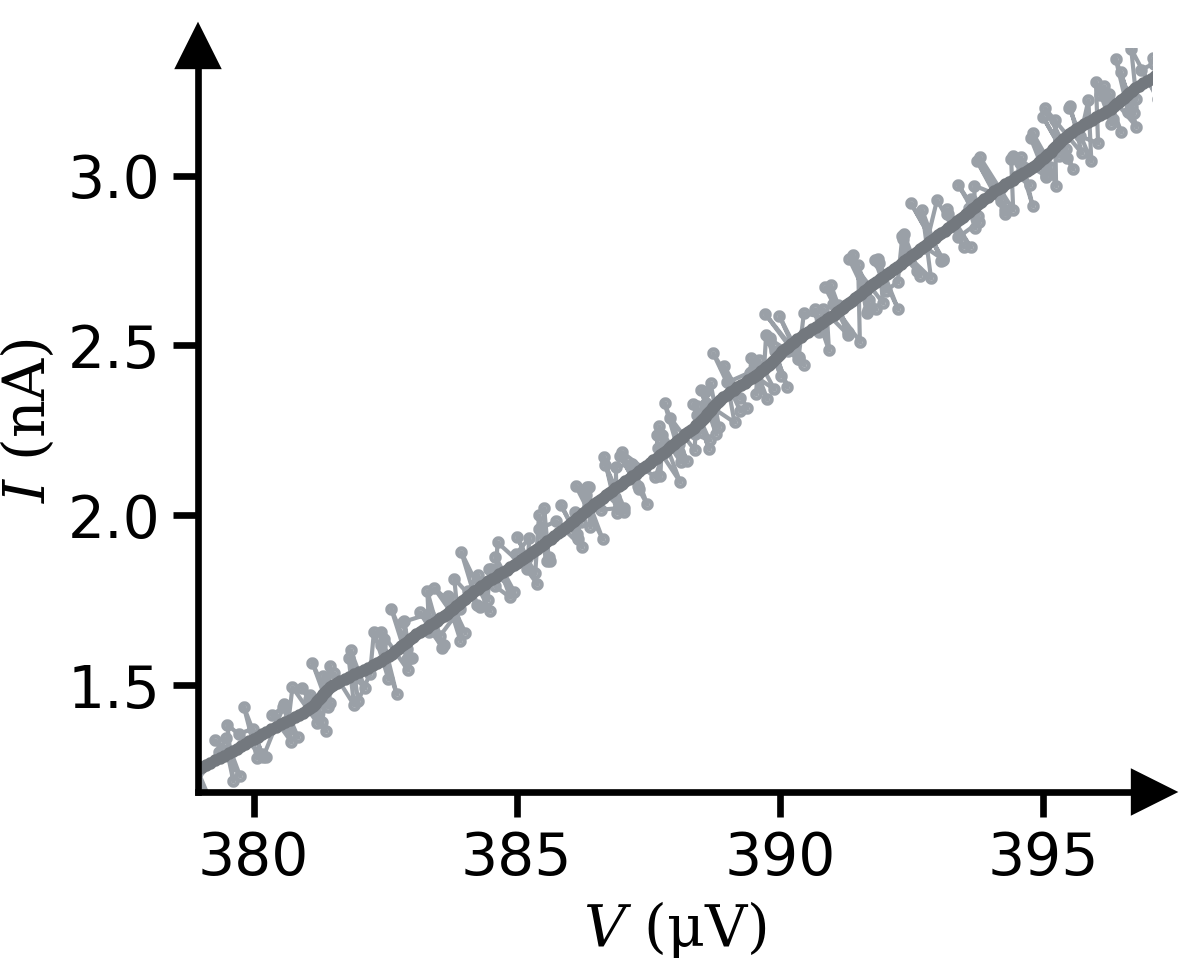

In [173]:
# raw + low-pass
fig, ax = sc.get_figure(figsize=figsize, padding=padding)

ax.plot(
    Vraw_uV,
    Iraw_nA,
    ".-",
    lw=0.5,
    color=sc.seegrau65,
)
ax.plot(
    Vlow_uV,
    Ilow_nA,
    ".-",
    lw=0.5,
    color=sc.seegrau100,
    label="$I_\mathrm{low-pass}$",
)

ax.set_ylim(ylim_glob)
ax.set_xlim(xlim_glob)

title = "methods/digital/eva_1"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

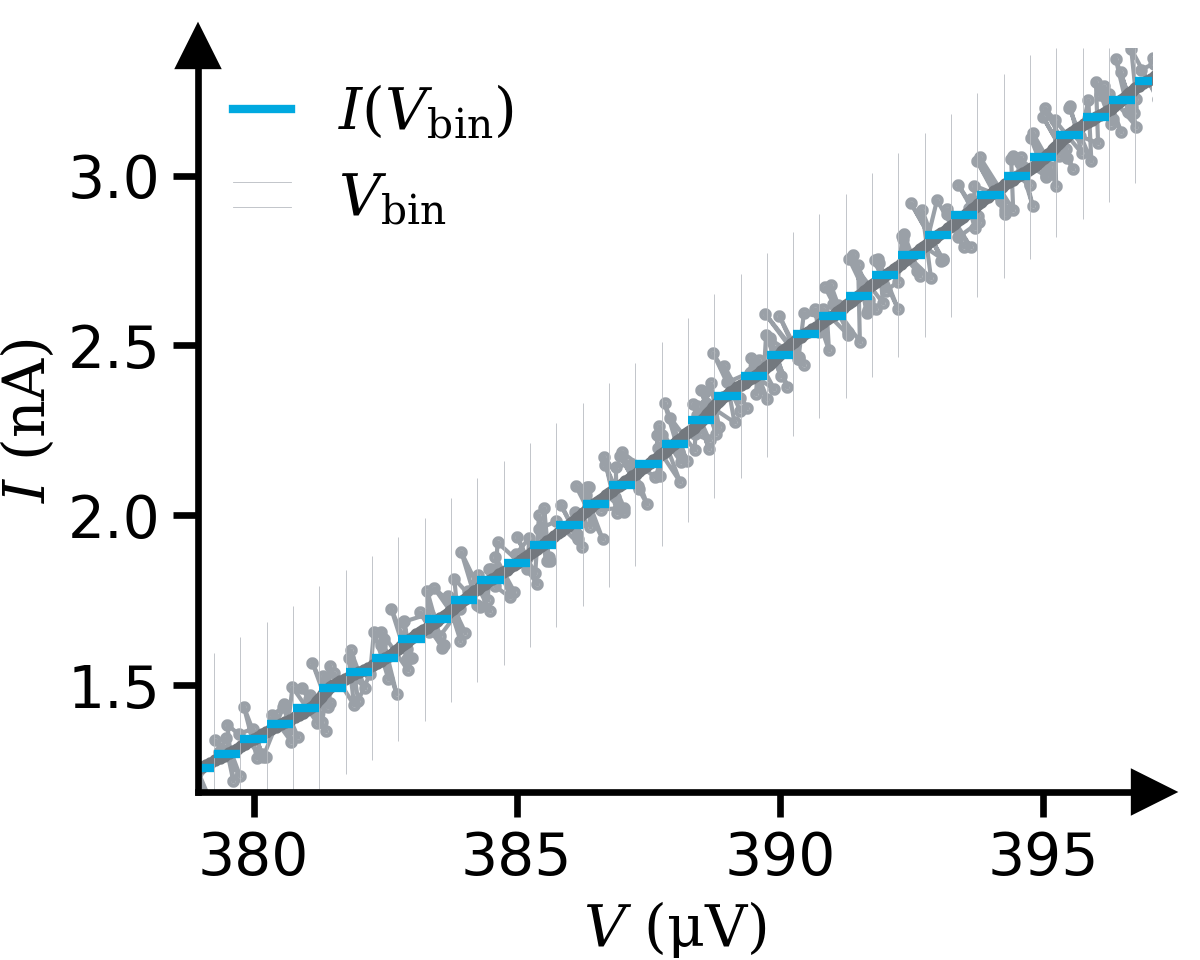

In [176]:
# bin(v) 2
fig, ax = sc.get_figure(figsize=figsize, padding=padding)

# Bild
ax.plot(
    Vraw_uV,
    Iraw_nA,
    ".-",
    lw=0.5,
    color=sc.seegrau65,
)
ax.plot(
    Vlow_uV,
    Ilow_nA,
    ".-",
    lw=0.5,
    color=sc.seegrau100,
)
for v, i in zip(Vbinv_uV, Ibinv_nA):
    ax.vlines(
        v - dV2_uV,
        max(ylim_glob[0], i - 0.3),
        min(ylim_glob[1], i + 0.3),
        color=sc.seegrau35,
        lw=0.1,
    )
    ax.hlines(
        i,
        v - dV2_uV,
        v + dV2_uV,
        color=sc.seeblau100,
        lw=1.0,
    )

ax.set_ylim(ylim_glob)
ax.set_xlim(xlim_glob)

# Ton
ax.plot([], [], "-", color=sc.seeblau100, lw=1.0, label="$I(V_\mathrm{bin})$")

handles, labels = ax.get_legend_handles_labels()
double_line = Line2D([], [], color=sc.seegrau35, linewidth=1.5)
handles.append(double_line)
labels.append("$V_\mathrm{bin}$")

leg = ax.legend(
    handles,
    labels,
    handlelength=1.0,
    loc="upper left",
    # bbox_to_anchor=(0.03, 1.0),
    frameon=False,
    fontsize=7,
    title_fontsize=7,
    # ncols=2,
    columnspacing=1.0,
    borderpad=0.1,  # reduces padding inside the legend box
    handler_map={double_line: HandlerDoubleLine()},
)

ax.set_ylim(ylim_glob)
ax.set_xlim(xlim_glob)

title = "methods/digital/eva_2"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

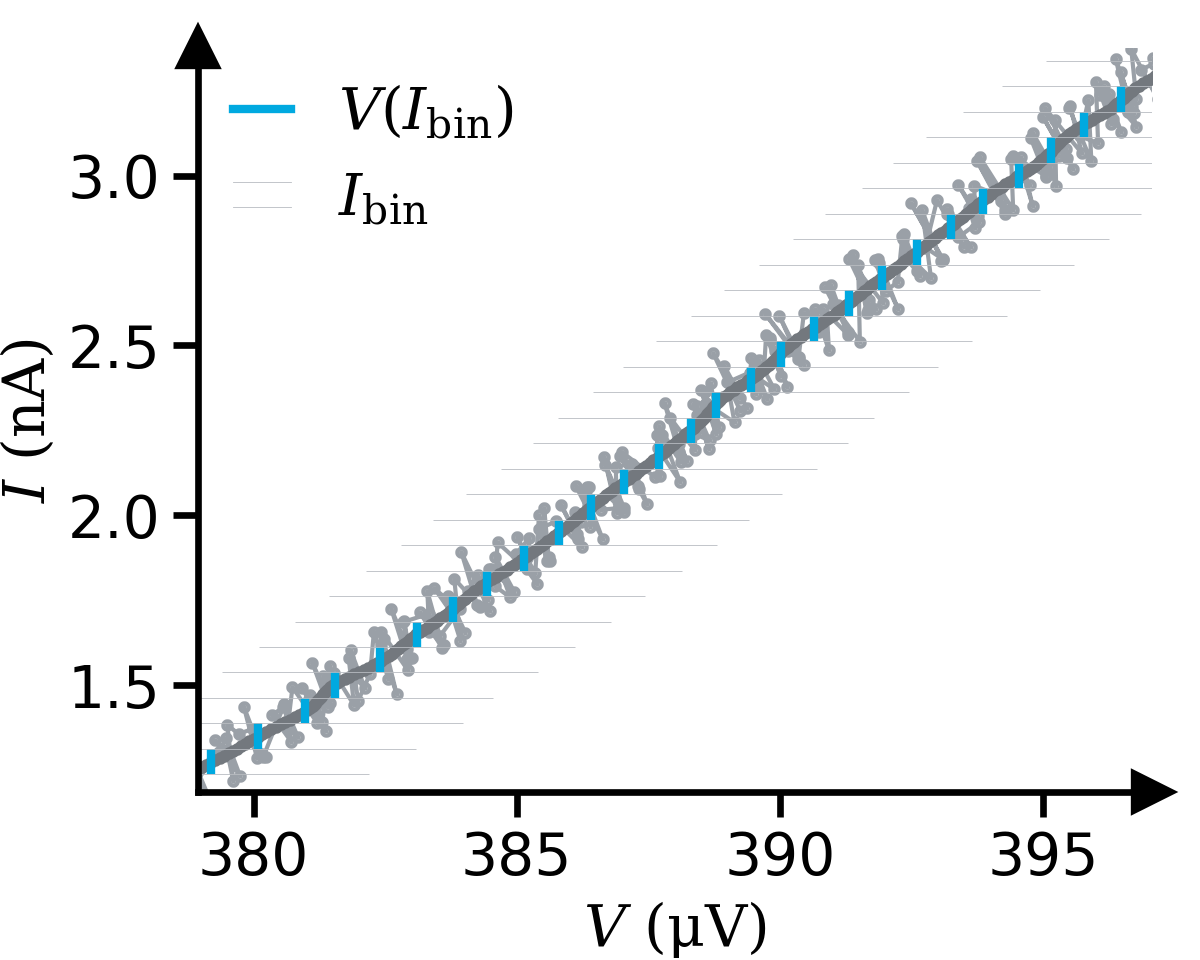

In [177]:
# bin(i) 3
fig, ax = sc.get_figure(figsize=figsize, padding=padding)

# Bild
ax.plot(
    Vraw_uV,
    Iraw_nA,
    ".-",
    lw=0.5,
    color=sc.seegrau65,
)
ax.plot(
    Vlow_uV,
    Ilow_nA,
    ".-",
    lw=0.5,
    color=sc.seegrau100,
)
for v, i in zip(Vbini_uV, Ibini_nA):
    ax.hlines(
        i - dI2_nA,
        max(xlim_glob[0], v - 3),
        min(xlim_glob[1], v + 3),
        color=sc.seegrau35,
        lw=0.1,
    )
    ax.vlines(
        v,
        i - dI2_nA,
        i + dI2_nA,
        color=sc.seeblau100,
        lw=1.0,
    )

ax.set_ylim(ylim_glob)
ax.set_xlim(xlim_glob)

# Ton
ax.plot([], [], "-", color=sc.seeblau100, lw=1.0, label="$V(I_\mathrm{bin})$")

handles, labels = ax.get_legend_handles_labels()
double_line = Line2D([], [], color=sc.seegrau35, linewidth=1.5)
handles.append(double_line)
labels.append("$I_\mathrm{bin}$")

leg = ax.legend(
    handles,
    labels,
    handlelength=1.0,
    loc="upper left",
    # bbox_to_anchor=(0.03, 1.0),
    frameon=False,
    fontsize=7,
    title_fontsize=7,
    # ncols=2,
    columnspacing=1.0,
    borderpad=0.1,  # reduces padding inside the legend box
    handler_map={double_line: HandlerDoubleLine()},
)

title = "methods/digital/eva_3"

sc.theory_layout(fig, ax, title, xlabel, ylabel)